Importation des bibliothèque

In [1]:
import numpy as np
import torch
import pandas as pd
import matplotlib.pyplot as plt 
from biopandas.pdb import PandasPdb
import nglview as nv
from scipy import stats

In [2]:
def view_structure(file_pdb):
    # 1. Charger le fichier généré
    view = nv.show_file(file_pdb)
    # 2. Vider les représentations par défaut
    view.clear_representations()
    # 3. Afficher toute la molécule de manière fine
    view.add_representation('licorice', selection='all', color='element')
    # 4. Mettre en surbrillance spéciale les atomes de Phosphore (les "noeuds" des liaisons phosphodiester)
    view.add_representation('spacefill', selection='_P', color='orange', radius=0.8)
    # 5. Rajouter un "tube" qui suit et met en évidence de façon continue le squelette phosphodiester (backbone)
    view.add_representation('tube', selection='backbone', color='red', radius=0.2)
    
    # # 6. Ajout d'un dégradé de couleur pour voir l'orientation 5' -> 3'
    # # Le schéma 'resindex' colore du bleu (début/5') au rouge (fin/3')
    # view.add_representation('cartoon', selection='nucleic', color='resindex')
    
    # 7. Centrer la vue
    view.center()
    # Afficher l'interface
    return view

In [26]:
view_structure("resultat/optimized_bs_dfire_1776073012_full_atom.pdb")

NGLWidget()

In [25]:
view_structure("resultat/optimized_bs_rasp_1776073439_full_atom.pdb")

NGLWidget()

In [24]:
view_structure("resultat/optimized_bs_rsRNASP_1776073904_full_atom.pdb")

NGLWidget()

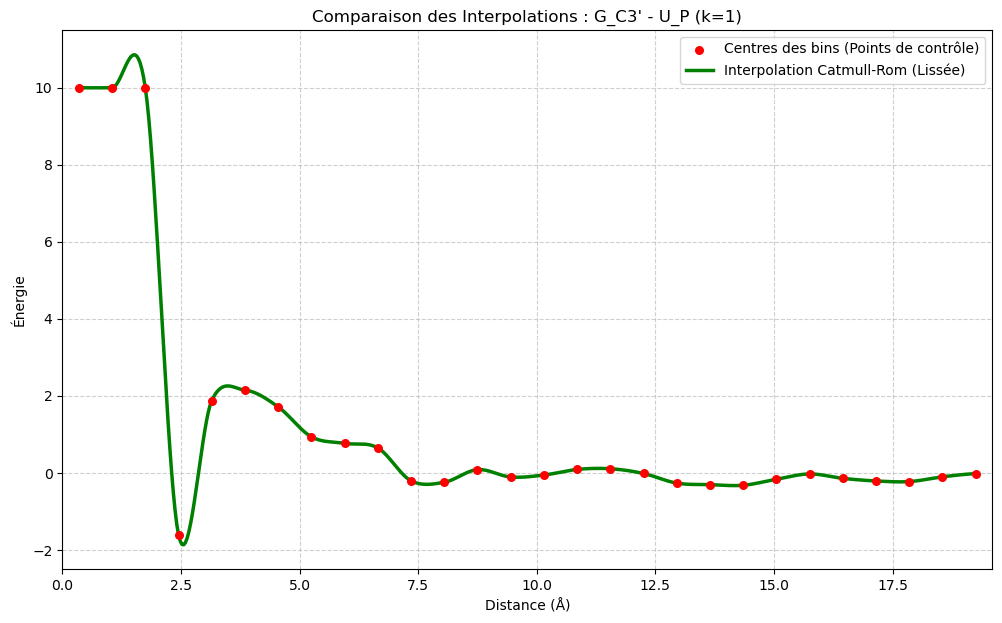

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from parse_dfire_potentials import load_dfire_potentials

def catmull_rom_spline(P0, P1, P2, P3, n_points=10):
    """
    Calcule les points d'une spline Catmull-Rom entre P1 et P2.
    P0, P1, P2, P3 sont les valeurs (y) aux points de contrôle.
    Hypothèse : points équidistants sur x.
    """
    t = np.linspace(0, 1, n_points)
    # Matrice Catmull-Rom
    # 0.5 * [ -t^3+2t^2-t, 3t^3-5t^2+2, -3t^3+4t^2+t, t^3-t^2 ]
    t2 = t*t
    t3 = t2*t
    
    f0 = -0.5*t3 + t2 - 0.5*t
    f1 = 1.5*t3 - 2.5*t2 + 1.0
    f2 = -1.5*t3 + 2.0*t2 + 0.5*t
    f3 = 0.5*t3 - 0.5*t2
    
    return f0*P0 + f1*P1 + f2*P2 + f3*P3

def plot_interpolation_dist(atom1, atom2, matrice_path="potentials/matrice_dfire.dat", k=1):
    """
    Affiche l'interpolation linéaire et Catmull-Rom pour deux types d'atomes.
    """
    try:
        potentials = load_dfire_potentials(matrice_path)
    except FileNotFoundError:
        print(f"Fichier non trouvé : {matrice_path}")
        return

    pair = (atom1, atom2)
    if pair not in potentials:
        pair = (atom2, atom1)
        if pair not in potentials:
            print(f"Paire {atom1}-{atom2} non trouvée.")
            return

    raw_values = potentials[pair]
    step = 0.7
    num_bins = len(raw_values)
    max_dist = 19.6
    
    x_raw = np.arange(num_bins) * step + (step / 2.0)
    y_raw = raw_values * k

    # 2. Interpolation Catmull-Rom
    # On étend les bords pour les points de contrôle P0 et P3
    extended_y = np.concatenate(([raw_values[0]], raw_values, [raw_values[-1]]))
    x_interp_cat = []
    y_interp_cat = []
    
    n_sub = 20 # points par segment
    for i in range(num_bins - 1):
        # Segments entre bin i et i+1
        # Points de contrôle : P0=i, P1=i+1, P2=i+2, P3=i+3 dans extended_y
        p0, p1, p2, p3 = extended_y[i], extended_y[i+1], extended_y[i+2], extended_y[i+3]
        segment_y = catmull_rom_spline(p0, p1, p2, p3, n_points=n_sub)
        segment_x = np.linspace(x_raw[i], x_raw[i+1], n_sub)
        
        x_interp_cat.extend(segment_x)
        y_interp_cat.extend(segment_y * k)

    # Affichage
    plt.figure(figsize=(12, 7))
    # plt.step(x_raw - step/2, y_raw, where='post', label='Données brutes (bins)', alpha=0.3, color='gray')
    plt.scatter(x_raw, y_raw, color='red', s=30, label='Centres des bins (Points de contrôle)', zorder=5)
    
    # plt.plot(x_interp_lin, y_interp_lin, label='Interpolation Linéaire (Actuelle)', color='blue', linestyle='--', linewidth=1.5)
    plt.plot(x_interp_cat, y_interp_cat, label='Interpolation Catmull-Rom (Lissée)', color='green', linewidth=2.5)
    
    plt.title(f"Comparaison des Interpolations : {atom1} - {atom2} (k={k})")
    plt.xlabel("Distance (Å)")
    plt.ylabel("Énergie")
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()
    plt.xlim(0, max_dist)

    
    plt.show()

# Test
plot_interpolation_dist("G_C3'", "U_P")


In [28]:
view_structure("resultat/optimized_bs_rsRNASP_1776087731_full_atom.pdb")

NGLWidget()

In [29]:
view_structure("resultat/optimized_bs_dfire_1776087564_full_atom.pdb")

NGLWidget()

In [30]:

view_structure("resultat/optimized_bs_rasp_1776087280_full_atom.pdb")


NGLWidget()